## Machine Learning Fundamentals (From Scratch)

This notebook contains implementations and explanations of core machine learning concepts built from scratch using Python and NumPy, including:

- Linear Regression using Gradient Descent  
- Polynomial Regression for non-linear data modeling  
- Normal Equation as an analytical solution for linear regression  
- Circle Fitting as an example of a non-linear optimization problem  

Each section includes mathematical intuition, implementation details, and visualizations to better understand how the models learn from data.

differniation of the function with respect to w is by eta: -0.21571601992479456
differniation of the function with respect to b is by eta : -0.030761018063910885
0.6517109220667983 0.05668724989180222
The Cost is 4.731201161641259
differniation of the function with respect to w is by eta: -0.13097349626023352
differniation of the function with respect to b is by eta : -0.018589026787408074
0.7826844183270318 0.07527627667921029
The Cost is 1.7277595845148748
differniation of the function with respect to w is by eta: -0.07952630372673619
differniation of the function with respect to b is by eta : -0.011199594225221148
0.862210722053768 0.08647587090443143
The Cost is 0.6271545540480344
differniation of the function with respect to w is by eta: -0.048292699109555595
differniation of the function with respect to b is by eta : -0.006713651577998445
0.9105034211633236 0.09318952248242987
The Cost is 0.22536558755380506
differniation of the function with respect to w is by eta: -0.0293307591

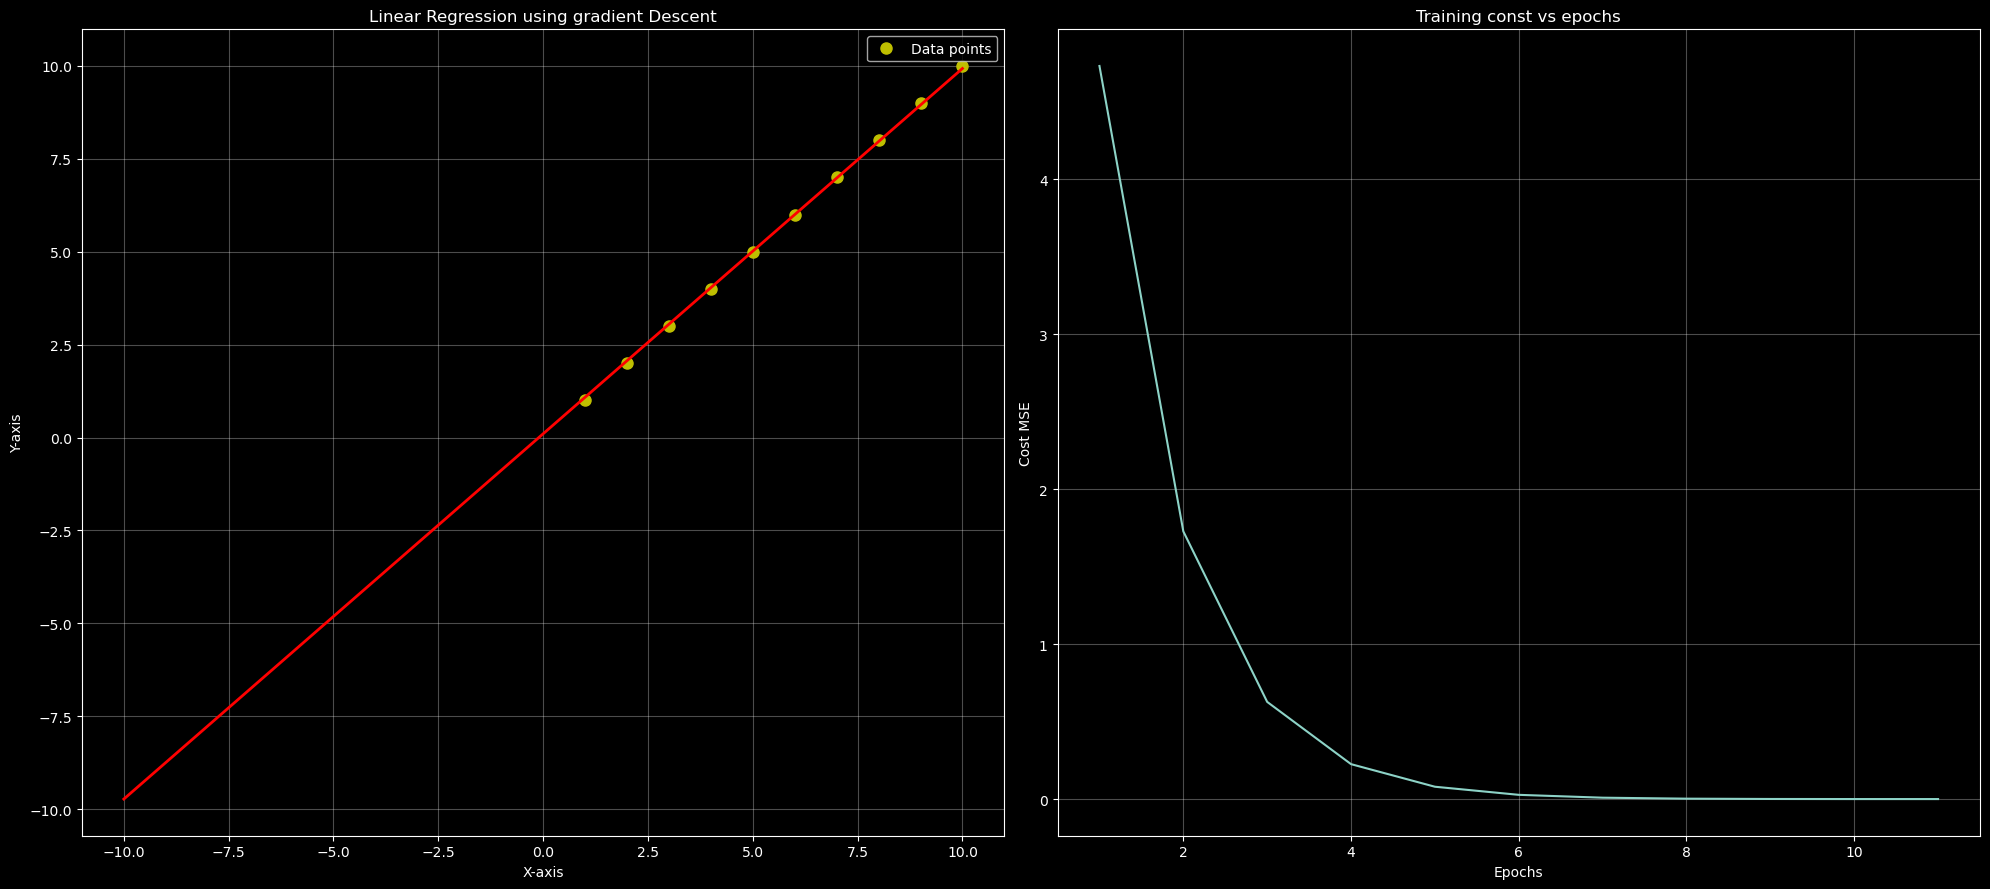

Final w : 0.9830
Final d : 0.9830
Final Cost : 0.0000
Training stoped at :11


In [2]:
import  numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")

x = np.arange(1,11)
y = np.arange(1,11)

plt.figure(figsize=(20,9),dpi=100)

plt.subplot(1,2,1)

plt.plot(x,y,'oy',markersize =8,label = 'Data points')

np.random.seed(2)

w = np.random.rand(1)[0]
b = np.random.rand(1)[0]

eta = 0.01
epochs = 1000

costVal = np.zeros(epochs)


for i in range (epochs):
    yhat = (w * x ) + b
    
    w = w - eta*(yhat - y) @ x / len(x)
    print(f"differniation of the function with respect to w is by eta: {eta*(yhat - y) @ x / len(x)}")
    b = b - eta * (np.mean(yhat - y ))
    print(f"differniation of the function with respect to b is by eta : {eta * (np.mean(yhat - y ))}")

    print(w,b)
    
    costVal[i] = 0.5 * (np.mean(yhat - y) ** 2)
    print(f"The Cost is {costVal[i]}")
    
    if costVal[i] < 1e-5 :
        break

xvals = np.arange(-10,11)
yvals = (w * xvals) + b

plt.plot(xvals,yvals,'r-',linewidth =2)

plt.title("Linear Regression using gradient Descent")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True,alpha=0.3)

plt.subplot(1,2,2)
plt.plot(range(1,i+2),costVal[:i+1])
plt.xlabel("Epochs")
plt.ylabel("Cost MSE")
plt.title("Training const vs epochs")
plt.grid(True,alpha= .3)

plt.tight_layout()
plt.show()

print(f"Final w :{w: 0.4f}")
print(f"Final d :{w: 0.4f}")
print(f"Final Cost :{costVal[i]: 0.4f}")
print(f"Training stoped at :{i+1}")





## Polynomial functions

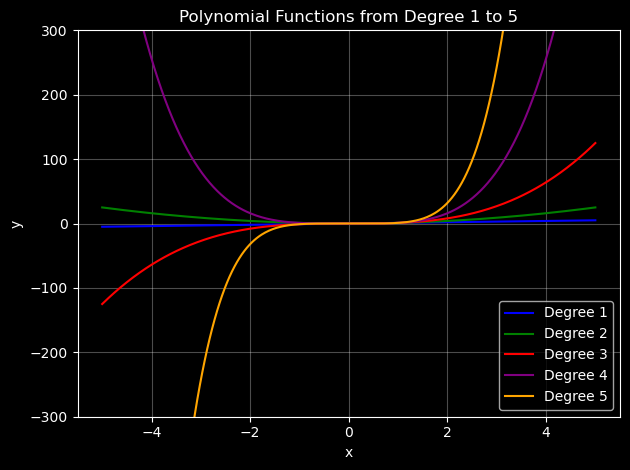

In [3]:
x = np.linspace(-5, 5, 400)
colors = ['blue', 'green', 'red', 'purple', 'orange']

for n, color in zip(range(1, 6), colors):
    y = x ** n
    plt.plot(x, y, label=f'Degree {n}', color=color)

plt.ylim(-300, 300)
plt.title('Polynomial Functions from Degree 1 to 5')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True,alpha=.3)
plt.tight_layout()
plt.show()

# Polynomial Regression and Normal Equation

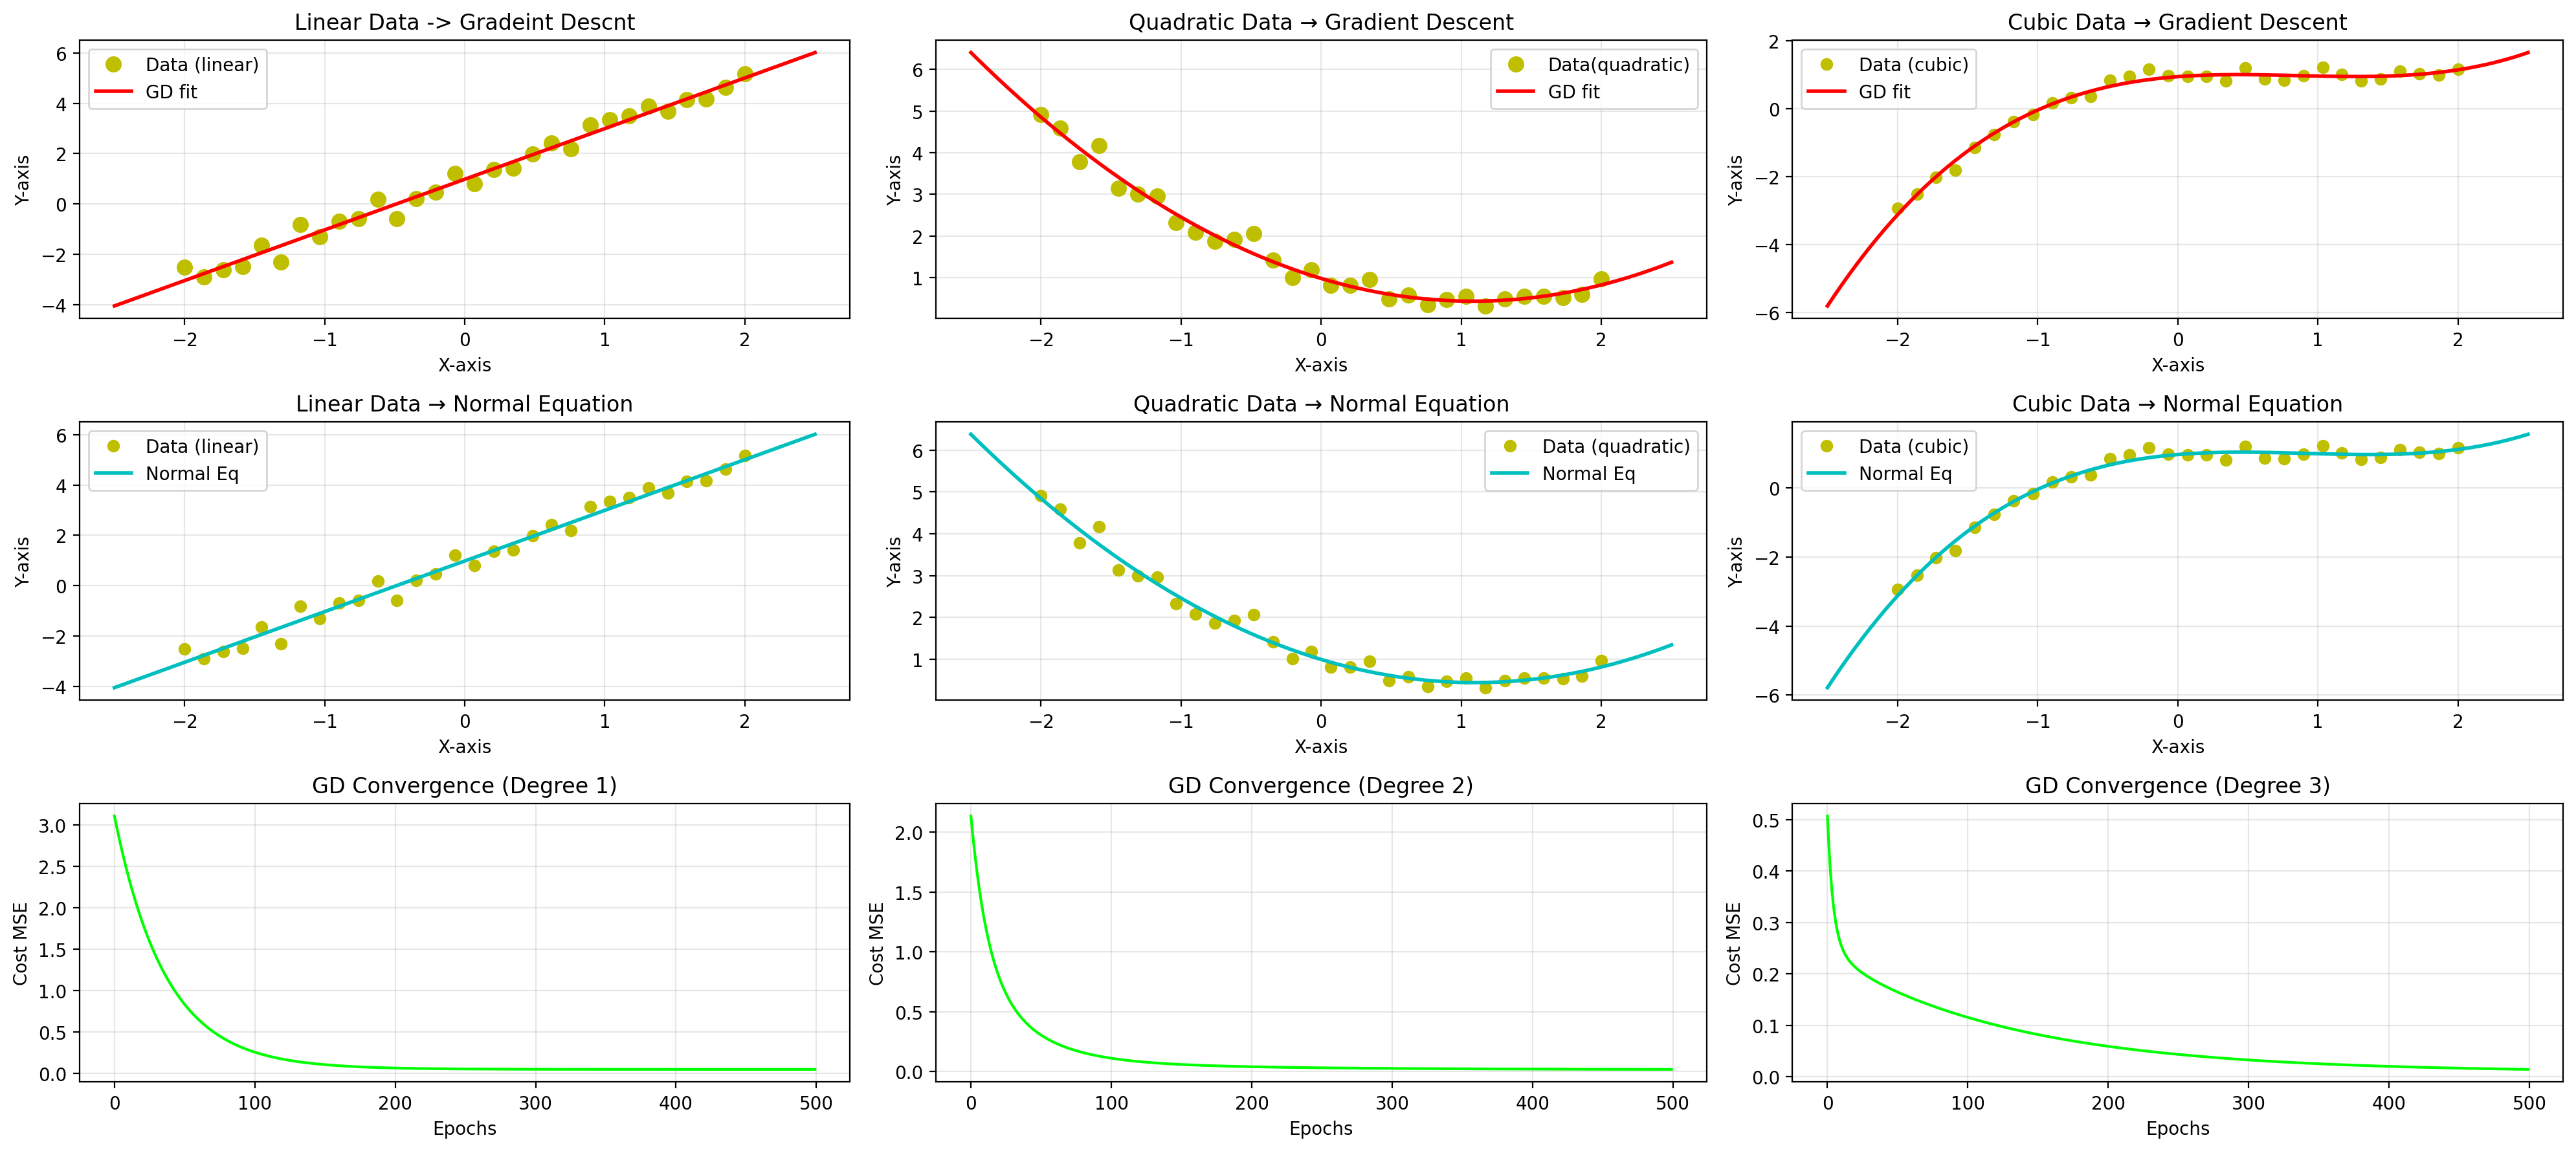

Gradient Descent vs Normal Equation Weights:

Degree 1 (Linear):
  GD:     y = 2.012x + 0.982
  Normal: y = 2.012x + 0.982
  True:   y = 2.000x + 1.000

Degree 2 (Quadratic):
  GD:     y = 0.465x² + -1.008x + 0.977
  Normal: y = 0.459x² + -1.008x + 0.992
  True:   y = 0.500x² - 1.000x + 1.000

Degree 3 (Cubic):
  GD:     y = 0.189x³ + -0.484x² + 0.312x + 0.950
  Normal: y = 0.181x³ + -0.493x² + 0.336x + 0.972
  True:   y = 0.200x³ - 0.500x² + 0.300x + 1.000

Standardization Demo (Degree 5):
Without standardization: Final cost = 0.082792 (lr=0.00001)
With standardization:    Final cost = 0.036379 (lr=0.1)
Normal Equation:         Final cost = 0.032252 (instant)


In [24]:
import numpy as np 
import matplotlib.pyplot as plt

def create_polynomial_features(x,degree):
    """Create polynomial features"""
    return np.column_stack([x**i for i in range(degree+1)])

def standardize_features(X):
    """Standardize features to have mean=0, std=1"""
    X_std = X.copy()
    # Don't standardize the bias term (first column of ones)
    X_std[:, 1:] = (X[:, 1:] - np.mean(X[:, 1:], axis=0)) / np.std(X[:, 1:], axis=0)
    return X_std

def polynomial_regression_gd(x,y,degree,learning_rate=0.01,epochs=1000,standardize=False):
    """Polynomial regression with gradient descent"""  
    X = create_polynomial_features(x,degree)

    if standardize:
        X_original = X.copy()
        X = standardize_features(X) # don't worry about understanding this at the current stage we will discuss it later (this is Z-scoring)


    np.random.seed(42)
    weights = np.random.rand(degree+1) * .1

    costs=[]
    for epoch in range (epochs):
        y_pred = X @ weights
        error = y_pred - y
        gradients =  (X.T @ error) / len (x)
        weights -= learning_rate* gradients;

        cost = np.mean(error** 2) / 2
        costs.append(cost)

        if cost < 1e-6 :
            break
    return weights , costs , (X_original if standardize else X)

def polynomial_regression_normal(x,y,degree,standardize=False) :
    X = create_polynomial_features(x, degree)

    if standardize:
        X_original = X.copy()
        X = standardize_features(X)


    # Normal equation : weights = (X^T X) ^-1 X^T y

    weights = np.linalg.inv(X.T @ X) @ X.T @ y

    return weights , (X_original if standardize else X)


# Create figure with original examples
plt.figure(figsize=(20,9), dpi =200)

# Example 1: Linear data (degree 1)
plt.subplot(3,3,1)
np.random.seed(1)
x1 = np.linspace(-2,2,30)
y1_true = 2*x1 +1 ;

y1 = y1_true + np.random.normal(0,0.3,30)

plt.plot(x1,y1,'oy',markersize=8,label= 'Data (linear)')

weights1_gd, _,X1 = polynomial_regression_gd(x1,y1,degree=1)
 
x_plot = np.linspace(-2.5,2.5,100)
X_plot = create_polynomial_features(x_plot,1)
y_plot = X_plot @ weights1_gd

plt.plot(x_plot,y_plot,'r-',linewidth=2,label='GD fit')
plt.title('Linear Data -> Gradeint Descnt')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True,alpha=.3)


# Example 2: Quadratic data (degree 2)
plt.subplot(3,3,2)
np.random.seed(2)
x2 = np.linspace(-2,2,30)
y2_true = 0.5*x2**2 - x2 + 1
y2 = y2_true + np.random.normal(0,.2,len(x2))

plt.plot(x2,y2,'oy',markersize=8,label= 'Data(quadratic)')
weights2_gd ,_,X2 =polynomial_regression_gd(x2,y2,degree=2)

X_plot = create_polynomial_features(x_plot,degree=2)
y_plot = X_plot @ weights2_gd

plt.plot(x_plot, y_plot, 'r-', linewidth=2, label='GD fit')
plt.title('Quadratic Data → Gradient Descent')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, alpha=0.3)


# Example 3: Cubic data (degree 3)
plt.subplot(3, 3, 3)
np.random.seed(3)
x3 = np.linspace(-2, 2, 30)
y3_true = 0.2*x3**3 - 0.5*x3**2 + 0.3*x3 + 1
y3 = y3_true + np.random.normal(0, 0.15, len(x3))

plt.plot(x3, y3, 'oy', markersize=6, label='Data (cubic)')
weights3_gd, _, X3 = polynomial_regression_gd(x3, y3, degree=3)

X_plot = create_polynomial_features(x_plot, 3)
y_plot = X_plot @ weights3_gd
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label='GD fit')
plt.title('Cubic Data → Gradient Descent')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, alpha=0.3)


# Same examples with Normal Equation
plt.subplot(3, 3, 4)
plt.plot(x1, y1, 'oy', markersize=6, label='Data (linear)')
weights1_ne, _ = polynomial_regression_normal(x1, y1, degree=1)

X_plot = create_polynomial_features(x_plot, 1)
y_plot = X_plot @ weights1_ne
plt.plot(x_plot, y_plot, 'c-', linewidth=2, label='Normal Eq')
plt.title('Linear Data → Normal Equation')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
plt.plot(x2, y2, 'oy', markersize=6, label='Data (quadratic)')
weights2_ne, _ = polynomial_regression_normal(x2, y2, degree=2)

X_plot = create_polynomial_features(x_plot, 2)
y_plot = X_plot @ weights2_ne
plt.plot(x_plot, y_plot, 'c-', linewidth=2, label='Normal Eq')
plt.title('Quadratic Data → Normal Equation')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
plt.plot(x3, y3, 'oy', markersize=6, label='Data (cubic)')
weights3_ne, _ = polynomial_regression_normal(x3, y3, degree=3)

X_plot = create_polynomial_features(x_plot, 3)
y_plot = X_plot @ weights3_ne
plt.plot(x_plot, y_plot, 'c-', linewidth=2, label='Normal Eq')
plt.title('Cubic Data → Normal Equation')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, alpha=0.3)

# Show cost convergence for gradient descent
degrees = [1, 2, 3]
data_sets = [(x1, y1), (x2, y2), (x3, y3)]

for idx, (degree, (x, y)) in enumerate(zip(degrees, data_sets)):
    plt.subplot(3, 3, idx + 7)
    weights, costs, _ = polynomial_regression_gd(x, y, degree, epochs=500)
    plt.plot(costs, 'lime')
    plt.xlabel('Epochs')
    plt.ylabel('Cost MSE')
    plt.title(f'GD Convergence (Degree {degree})')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
print("Gradient Descent vs Normal Equation Weights:\n")

print("Degree 1 (Linear):")
print(f"  GD:     y = {weights1_gd[1]:.3f}x + {weights1_gd[0]:.3f}")
print(f"  Normal: y = {weights1_ne[1]:.3f}x + {weights1_ne[0]:.3f}")
print(f"  True:   y = 2.000x + 1.000\n")

print("Degree 2 (Quadratic):")
print(f"  GD:     y = {weights2_gd[2]:.3f}x² + {weights2_gd[1]:.3f}x + {weights2_gd[0]:.3f}")
print(f"  Normal: y = {weights2_ne[2]:.3f}x² + {weights2_ne[1]:.3f}x + {weights2_ne[0]:.3f}")
print(f"  True:   y = 0.500x² - 1.000x + 1.000\n")

print("Degree 3 (Cubic):")
print(f"  GD:     y = {weights3_gd[3]:.3f}x³ + {weights3_gd[2]:.3f}x² + {weights3_gd[1]:.3f}x + {weights3_gd[0]:.3f}")
print(f"  Normal: y = {weights3_ne[3]:.3f}x³ + {weights3_ne[2]:.3f}x² + {weights3_ne[1]:.3f}x + {weights3_ne[0]:.3f}")
print(f"  True:   y = 0.200x³ - 0.500x² + 0.300x + 1.000\n")

# Demonstrate standardization benefit for higher degree
print("="*60)
print("Standardization Demo (Degree 5):")
print("="*60)

x5 = np.linspace(-2, 2, 40)
y5_true = 0.1*x5**5 - 0.2*x5**3 + 0.5*x5
y5 = y5_true + np.random.normal(0, 0.3, len(x5))

# Without standardization
weights_no_std, costs_no_std, _ = polynomial_regression_gd(x5, y5, degree=5, learning_rate=0.00001, epochs=1000)
print(f"Without standardization: Final cost = {costs_no_std[-1]:.6f} (lr=0.00001)")

# With standardization
weights_std, costs_std, _ = polynomial_regression_gd(x5, y5, degree=5, learning_rate=0.1, epochs=1000, standardize=True)
print(f"With standardization:    Final cost = {costs_std[-1]:.6f} (lr=0.1)")

# Normal equation
weights_normal, _ = polynomial_regression_normal(x5, y5, degree=5)
y_pred_normal = create_polynomial_features(x5, 5) @ weights_normal
cost_normal = np.mean((y_pred_normal - y5)**2) / 2
print(f"Normal Equation:         Final cost = {cost_normal:.6f} (instant)")



# Circle Fitting with Gradient descent

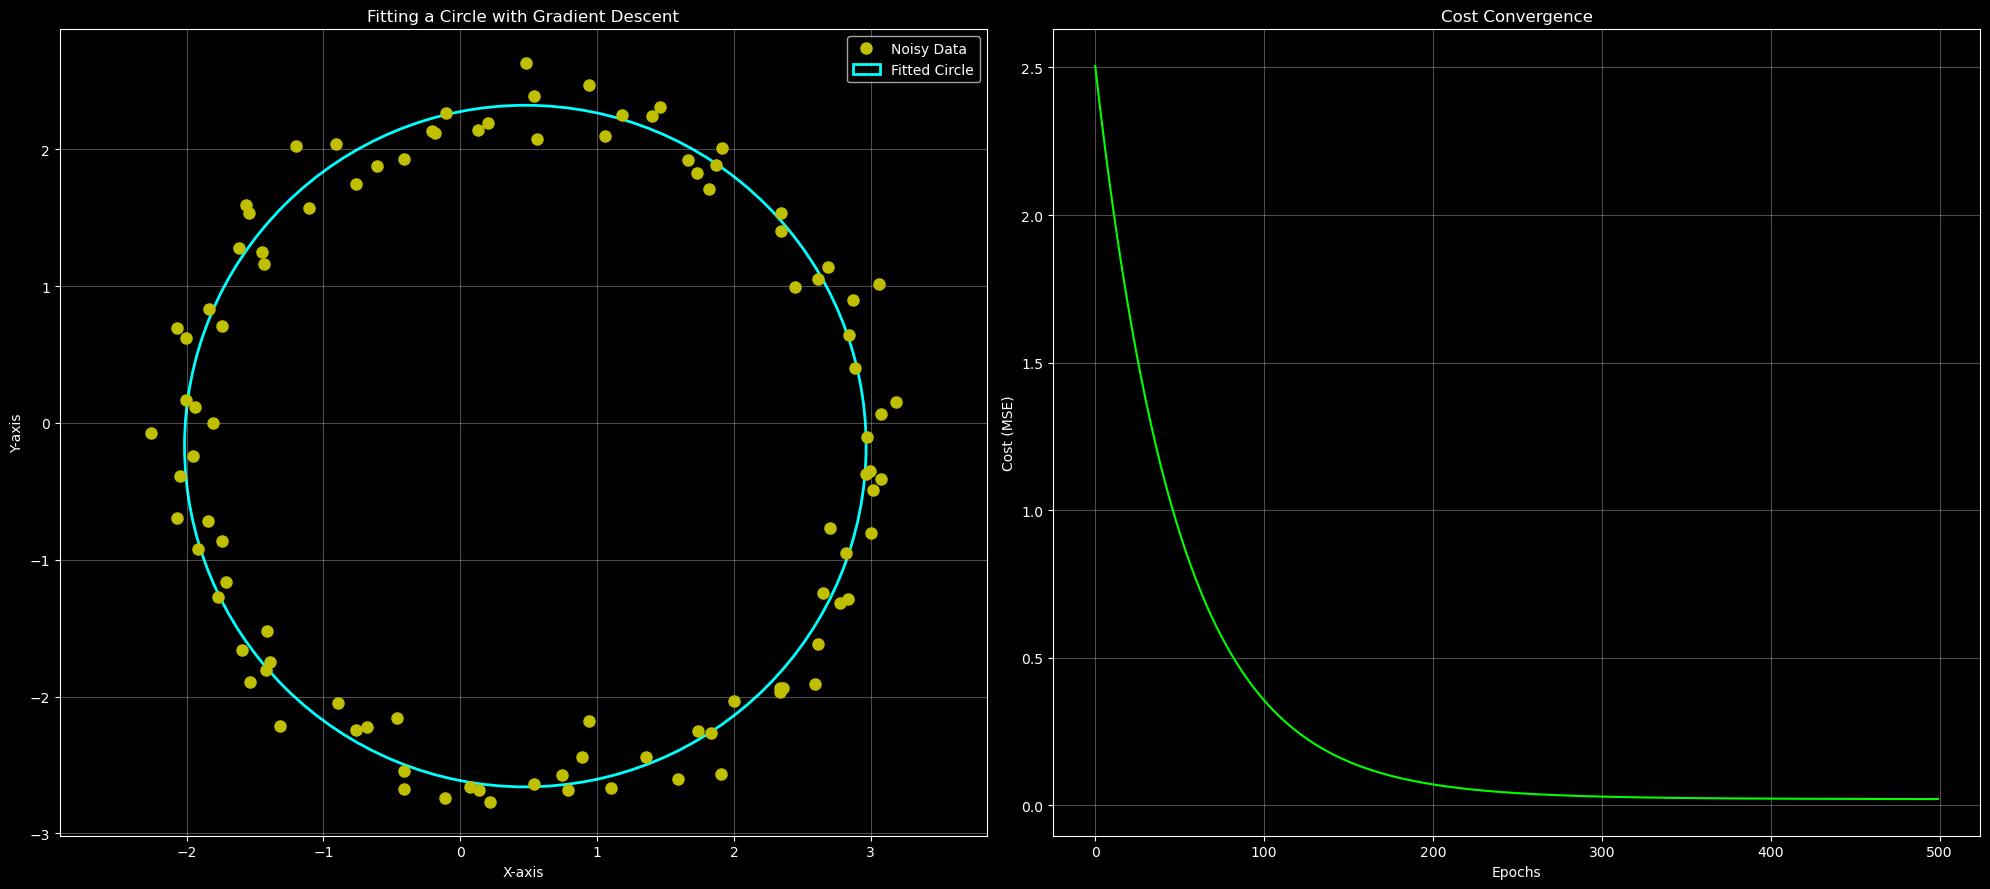

Circle Fitting Results:

Learned parameters: h=0.475, k=-0.170, r=2.490
True parameters:    h=0.500, k=-0.200, r=2.500


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

plt.style.use('dark_background')

#Generate noisy data points on circle

np.random.seed(42)
 
h_true , k_true ,r_true = 0.5, -0.2 , 2.5
theta = np.linspace(0,2 * np.pi , 100)
x_data = h_true + r_true * np.cos(theta) + np.random.normal(0,0.15,100)
y_data = k_true + r_true * np.sin(theta) + np.random.normal(0,0.15,100)


# Initial guess for the circle's parameters, h,k represent the center of the circle.
h , k , r = 0.0 ,0.0 , 1.0 
learning_rate = 0.01
ephocs = 500
costs = []

for epoch in range(ephocs):

    # Calculate distances and errors (part of the cost function)
    distances = np.sqrt((x_data -h)**2 + (y_data - k)**2)

    errors = distances - r  

    # Calculate gradients for each parameter
    grad_h = np.mean(errors * ((h - x_data)/ distances)) 
    grad_k = np.mean(errors * ((k - y_data)/ distances)) 
    grad_r = -np.mean(errors)

    h -= learning_rate * grad_h
    k -= learning_rate * grad_k
    r -= learning_rate * grad_r


    cost = np.mean(errors**2)
    costs.append(cost)

plt.figure(figsize=(20,9))

plt.subplot(1,2,1)
plt.plot(x_data,y_data,'oy',markersize= 8,label = 'Noisy Data')
fit_circle = Circle((h,k),r, color='cyan', fill= False, linewidth =2,label ='Fitted Circle')
plt.gca().add_patch(fit_circle)
plt.title('Fitting a Circle with Gradient Descent')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal') # Important for circles to look like circles!


# Plot convergence
plt.subplot(1, 2, 2)
plt.plot(costs, 'lime')
plt.title('Cost Convergence')
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Print the final learned vs true parameters
print("Circle Fitting Results:\n")
print(f"Learned parameters: h={h:.3f}, k={k:.3f}, r={r:.3f}")
print(f"True parameters:    h={h_true:.3f}, k={k_true:.3f}, r={r_true:.3f}")


